# Model-based reinforcement learning tutorial

Prepared by Mihály Bányai, 2026. mihaly.s.banyai@gmail.com, https://visionlab-ceu.org/people/mihaly-banyai/ 

In [131]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
from Levenshtein import distance as levenshtein_distance
from ipynb.fs.defs.AIT26_Tutorial4_RL import transition_probs_from_map, plot_gridworld, evaluate_Q

# The value iteration algorithm

This algorithm takes a known model of transition probabilities and rewards, and computes a state-value function (V) as well as an action-value function (Q). It is a numerical iteration that aims to satisfy the Bellman consistency equations. 

Number of sweeps to convergence: 40 ( 207360 operations)


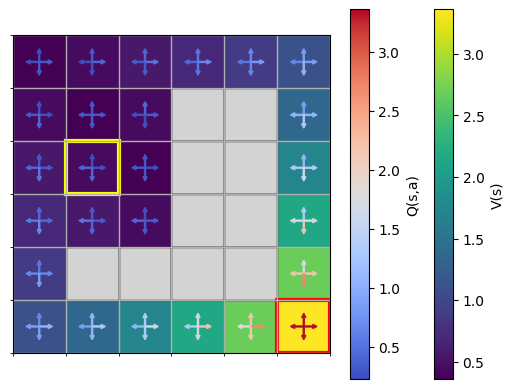

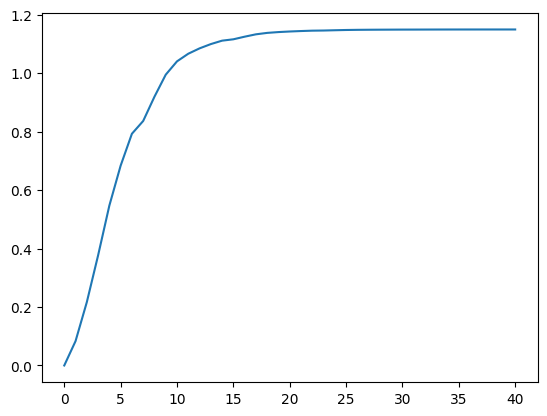

In [142]:
def value_iteration(T, R, gamma, delta_threshold):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    V = np.zeros((n_states))
    Q = np.zeros((n_states, n_actions))
    value_sums = [0]  # we record how the sum of value changes over the course of the iteration 
    delta = np.inf
    iter = 0
    while delta > delta_threshold and iter < 100:
        delta = 0
        for s in range(n_states):
            deltas_per_action = np.zeros((n_actions))
            for a in range(n_actions):
                Q[s, a] = 0
                for s_prime in range(n_states):
                    Q[s, a] += T[s, s_prime, a] * (R[s] + gamma * V[s_prime])
                deltas_per_action[a] = Q[s, a] - V[s]
            delta = np.maximum(delta, deltas_per_action.max())
            V[s] = Q[s, :].max()
        iter += 1
        value_sums.append(V.sum() / n_states)
    print("Number of sweeps to convergence:", iter, "(", iter * n_states**2 * n_actions, "operations)")
    return V, Q, value_sums

state_map = [
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 3]
]

init_state = 13
T_map, R_map = transition_probs_from_map(state_map, start_state=init_state)

V, Q, value_sums = value_iteration(T=T_map, R=R_map, gamma=0.8, delta_threshold=0.0001)
plot_gridworld(state_map, init_state, q_function=Q)
plt.plot(value_sums)

## Independent work - how does value iteration scale?
1. Implement an operation counter in the algorithm
2. generate a series of larger and larger environments
3. run value iteration on all of them and plot the computational cost as a function of the number of states

# The Dyna algorithm with proritised sweeping

The Dyna algorithm learns the model (T, R) using the observations of the agent, and after each step uses synthetic experiences, replayed from the model, to update the Q function.
See description by Leslie Kaelbling: https://www.cs.cmu.edu/afs/cs/project/jair/pub/volume4/kaelbling96a-html/node29.html 

The prioritised sweeping algorithm forms a queue of observerved transitions based on a particular notion of how useful it would be to replay them, namely if they lead to a state where a big update happened.
See description by Richard Sutton: http://incompleteideas.net/book/first/ebook/node98.html 

R: 165.0


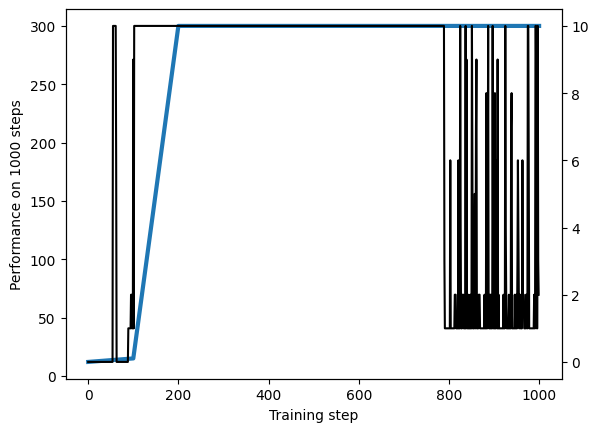

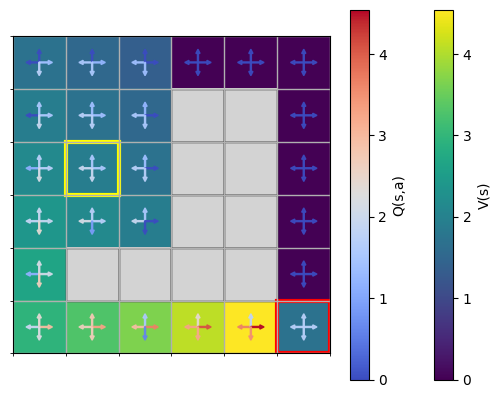

In [148]:
# calculating the TD error, in a separate function to be used for both real experiences and replays
def TD_error(act_state, next_state, action, Q, R, gamma):
    return R[next_state] + gamma * Q[next_state, :].max() - Q[act_state, action]

# the priority queue for prioritised sweeping
def insert_into_priority(priority_queue, priority, act_state, next_state, action):
    if priority < 1e-3:
        return
    # check if the transition is already in the queue
    for pi, p in enumerate(priority_queue):
        oldp, s1, s2, a = p
        if s1==act_state and s2==next_state and a==action:
            # if it is, and with a higher priority, just leave it there, if with a lower one, delete the old entry
            if oldp > priority:
                return
            else:
                del priority_queue[pi]
    # insert the episode into the queue such that priorities are ordered
    for i, (old_prior, *_) in enumerate(priority_queue):
        if priority > old_prior:  # strictly greater → comes earlier
            priority_queue.insert(i, (priority, act_state, next_state, action))
            return
    priority_queue.append((priority, act_state, next_state, action))

# separate what the environment does into a function, so it's obvious what's not available for learning
def environment_dynamics(T, R, act_state, action):
    states = list(range(R.shape[0]))
    next_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten()).item()
    reward = R[next_state]
    return next_state, reward


def dyna(T, R, gamma, max_step, alpha, epsilon, k, init_state, eval_interval=None, eval_step=1000):

    n_states = R.shape[0]
    n_actions = T.shape[2]
    states = list(range(n_states))
    actions = list(range(n_actions))

    Q = np.zeros((n_states, n_actions))
    action_counter = np.zeros((n_states, n_actions))
    T_learned = np.zeros((n_states, n_states, n_actions))
    R_learned = np.zeros(n_states)
    priority_queue = []

    actual_replays_per_step = np.zeros(max_step)
    eval_perfs = [evaluate_Q(T, R, init_state, Q, eval_step) if eval_interval is not None else 0]
    collected_reward = 0

    act_state = init_state
    for i in range(max_step):

        # the epsilon-greedy action selection rule with a bit of elaboration to motivate trying new actions
        if random.uniform(0, 1) < epsilon:
            actions_never_taken = np.argwhere(action_counter[act_state, :] == 0).flatten().tolist()
            if len(actions_never_taken) > 0:
                action = random.choice(actions_never_taken)
            else:
                not_best_actions = np.argwhere(Q[act_state, :] < np.amax(Q[act_state, :])).flatten().tolist()
                if len(not_best_actions) > 0:
                    action = random.choice(not_best_actions)
                else:
                    action = random.choice(actions)
        else:
            best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
            action = random.choice(best_actions)
        action_counter[act_state, action] += 1

        # the next state is chosen according to the state-action transition probability tensor
        # this is the only place where we use the ground-truth T and R, when we produce the environment's response
        next_state, reward = environment_dynamics(T, R, act_state, action)
        collected_reward += reward

        # model learning, assuming a deterministic environment
        R_learned[next_state] = reward
        T_learned[act_state, next_state, action] = 1

        priority = np.abs(TD_error(act_state, next_state, action, Q, R_learned, gamma))
        insert_into_priority(priority_queue, priority, act_state, next_state, action)

        # replaying k prioritised samples from the model
        for j in range(k):
            # if there are no non-zero priority actions, stop
            if len(priority_queue) == 0:
                break
            actual_replays_per_step[i] += 1
            # choose the highest-priority state-action pair and remove it from the queue
            _, rep_s0, rep_s1, rep_a = priority_queue.pop(0)
            # do a Q-update using the replayed action
            Q[rep_s0, rep_a] += alpha * TD_error(rep_s0, rep_s1, rep_a, Q, R_learned, gamma)
            # check which other actions from which states can lead to rep_s0
            for s in range(n_states):
                if not s == rep_s0:
                    for a in range(n_actions):
                        td = TD_error(s, rep_s0, a, Q, R_learned, gamma)
                        if T_learned[s, rep_s0, a] > 0 and td > 0.01:
                            predecessor_priority = np.abs(td)
                            insert_into_priority(priority_queue, predecessor_priority, s, rep_s0, a)

        # performance logging
        if eval_interval is not None and i % eval_interval == 0:
            eval_perfs.append(evaluate_Q(T, R, init_state, Q, eval_step))
        # iterating the state signal for the next step
        act_state = next_state

    if eval_interval is not None:
        plt.plot(np.array(range(len(eval_perfs))) * eval_interval , eval_perfs, linewidth=3)
        plt.xlabel("Training step")
        plt.ylabel("Performance on %d steps" % eval_step)

    print("R:", collected_reward)

    return Q, actual_replays_per_step

random.seed(3)    
Q, replays = dyna(T_map, R_map, gamma=0.9, max_step=1000, alpha=0.2, epsilon=0.3, k=10, init_state=init_state, eval_interval=100, eval_step=1000)

# plot how many replays happened in each trial
ax2 = plt.gca().axes.twinx()
ax2.plot(replays, color="black")

plot_gridworld(state_map, init_state, q_function=Q)


# Independent work - balance of planning vs. acting
1. How many replays does it make sense to use?

# Finding replay in neural data

## Place cell activity from the Buzsáki lab  
homepage: https://buzsakilab.com/wp/  
source: https://crcns.org/data-sets/hc/hc-11/about-hc-11  
mouse name: Achilles

For detailed information please follow the link above. In brief, the rat was running back and forth on a linear track for reward. The activity of multiple hippocampal neurons have been recorded together with the position of the animal. Spike times and positions are measured in second and meter, respectively.

In [130]:

pos = np.genfromtxt("datasets/HC11/position_mm.txt")
spikes = np.genfromtxt("datasets/HC11/spikes_ms.txt")

# cells have been ordered based on the location of their place fields
cellindex = np.array([0,  40,  47,  45,  44,  41,  52,  85,  30, 109,  87,  73,   7,
        61,  64,  90,  10, 106,  25, 111,  96, 114,  51,  42,  98,   1,
        33, 104, 116,   8,  23,  79,   5,  36,  20,  53,  99,  83,  16,
        24,  78,  43,  22,   3,  12,  29,  84,   9,  19,  18,  57, 100,
       118,  65,  38,  67, 102,  35, 112,  94,   6,  66,  69, 105, 101,
        74, 113, 117,  80,  60,  21,  15,  58, 110,  28,  34,  77,  81,
       115,  55,  91,  86,  76,  27,  97,  89, 119,  75,  26,  17,  95,
        93,  31,  46,  54,  14,  88,  62,   2,  11,  56,  68,  48, 108,
        63,  13,  49, 103,  72,  59,  70,  37,  39,  50,  82,  71, 120,
        32,  92,   4, 107])

# the time window around a maze run
tmin = 18310
tmax = 18325

ii_spikes = np.flatnonzero((spikes[:,0] > tmin) & (spikes[:,0] < tmax))
sp = spikes[ii_spikes,:]

ii_pos = np.flatnonzero((pos[:,0] > tmin) & (pos[:,0] < tmax))
tx = pos[ii_pos,:]

# Looking for replays using a Levenshtein score

A replay is a sequence of cell activations that can be thought of as a codeword. Words can be compared to each other using the Levenshtein distance (https://en.wikipedia.org/wiki/Levenshtein_distance), that measures how many simple changes we have to make to one word to get to the other.

The main difficulty with replays is that they happen on a timescale that is much faster than the animal's movement, so we have to abstract away time and convert activation sequences into abstract words.

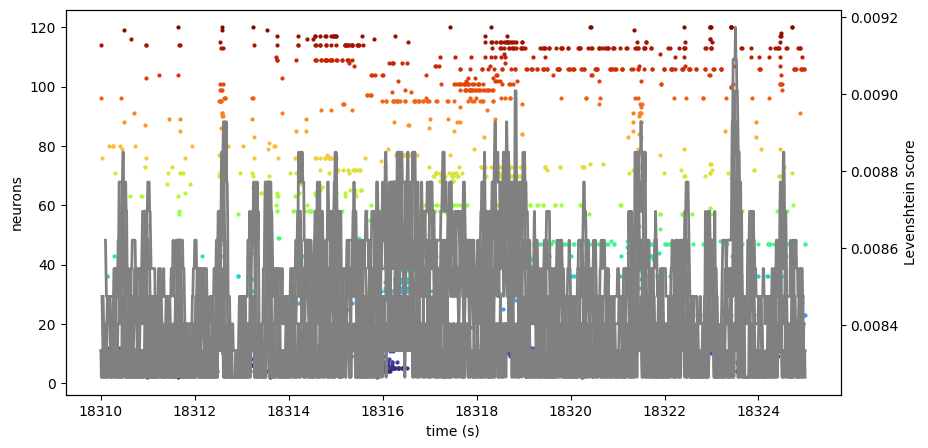

In [164]:
import copy

n_cell = len(cellindex)
n_spike = sp.shape[0]

cmap = mpl.colormaps['turbo']
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()

for i_cell in np.arange(len(cellindex)):
    idx = np.flatnonzero(sp[:,1] == i_cell)
    if (len(idx) > 0):
        jj = np.flatnonzero(cellindex == i_cell)
        ax.scatter(sp[idx,0], np.ones(len(idx)) * jj, s=4, c=cmap(jj/121), zorder=2)
        
ax2.set_ylabel('Levenshtein score')
ax.set_ylabel('neurons')
ax.set_xlabel('time (s)')

reference_code = copy.copy(np.flip(cellindex))

# the moving window for the replay matching algorithm
for window_width_s in [0.005, 0.01, 0.05, 0.1, 0.2]:
    window_step_s = 0.01

    replay_scores = []
    window_midpoints = []

    act_window_start = tmin
    act_window_end = act_window_start + window_width_s

    while act_window_end <= tmax:

        # figure out when the mean spike time of each cell within the current window is
        act_spike_count = np.zeros((n_cell))
        act_mean_spike_time = np.zeros((n_cell))
        for spike_idx in range(n_spike):
            spike_time = sp[spike_idx, 0]
            spike_cell = int(sp[spike_idx, 1])
            if spike_time >= act_window_start and spike_time < act_window_end:
                act_spike_count[spike_cell] += 1
                act_mean_spike_time[spike_cell] += spike_time
        act_mean_spike_time[act_spike_count > 0] /= act_spike_count[act_spike_count > 0]

        # establish the order in which the cells that spiked at all did so, this is our word
        cells_spiked = np.flatnonzero(act_spike_count)
        ordering_indices = np.argsort(act_mean_spike_time[cells_spiked])
        codeword = cells_spiked[ordering_indices]

        # the original ordering by place field locations in the cellindex array is the reference codeword
        replay_score = 1. / levenshtein_distance(codeword, reference_code)
        replay_scores.append(replay_score)

        # shift the window for the next iteration
        window_midpoints.append(act_window_start + (act_window_end - act_window_start) / 2)
        act_window_start += window_step_s
        act_window_end += window_step_s

    ax2.plot(window_midpoints, replay_scores, c='grey', zorder=1, linewidth=2)


## Independent work - the time scale of replay

- assess the time scale of mental replay in relation to the time scale of actual movement
- is there a single time scale or multiple?

## Homework problems

### 1. Explore the replay sequences found by the Levenshtein score
- compare the ones before and after the actual movement of the animal

### 2. Implement environments with sudden change
- compare Q-learning to Dyna-PS

### 3. Implement tree-search-based planning using a model
- estimate the value of a particular action in a particular state by rolling out possible state sequences to a finite depth
- try out cuts in terms of probability or value

### 4. Use tree search to plan in the belief MDP of a 2-armed bandit problem
- assess how the belief states would transition into each other upon any observation
- estimate the value of the two actions using a finite-depth tree search